# 04 — H4 protection vs possession audit (human review)

Decomposes `4.6` care and exhaustively inspects both `4.7` topics.
**Protection requires an external threat**; partner-as-danger → control, not protection.

Saved audits + packets only; rating cells stay blinded.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

cwd = Path.cwd().resolve()
root = cwd
for _ in range(6):
    if (root / "configs").is_dir() and (root / "src").is_dir():
        break
    root = root.parent
sys.path.insert(0, str(root))

from src.stage11_refined_construct_analysis.analysis import notebook_helpers as nh
from src.stage11_refined_construct_analysis.analysis import review_display as rd
from src.stage11_refined_construct_analysis.analysis.constructs import normalize_code
from src.stage11_refined_construct_analysis.lookup import load_topic_lookup, topics_for_leaves

ctx = nh.setup("04_h4_protection_possession_audit")
cfg = ctx.cfg
HYP = "H4"
CODE_COL = "care_protection_code"

Project root : /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus
Config       : configs/stage11/refined_constructs.yaml
Run          : v4_l12_granular_final_call49
Outputs      : results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/04_h4_protection_possession_audit


## 1. Overview — labels with codes

In [2]:
lookup = load_topic_lookup(cfg)
master = nh.load_master(cfg)
h4 = master[master[CODE_COL].notna()].copy()
h4["code_norm"] = h4[CODE_COL].map(normalize_code)
print(f"H4-coded topics: {len(h4)}")

overview = rd.annotation_overview(h4, CODE_COL)
display(overview[["topic", "taxonomy", "code", "code_norm", "mixed", "agree"]])
ctx.save_table(overview, "h4_topic_overview_labeled")
display(h4[CODE_COL].value_counts().to_frame("n"))
display(h4["code_norm"].value_counts(dropna=False).to_frame("n_norm"))

H4-coded topics: 32


,topic,taxonomy,code,code_norm,mixed,agree
0,6 — Whispered Reassurance,"4.6 — Emotional Safety, Reassurance & Caretaking",H4_1,H4_1,False,
1,31 — Keeping Watch While Others Sleep,"4.6 — Emotional Safety, Reassurance & Caretaking",PROTECTION,H4_5,True,"H1,H4"
2,36 — Eagerly Offering to Help,"4.6 — Emotional Safety, Reassurance & Caretaking",4.6.1,H4_1,False,"H1,H3,H4"
3,45 — Reassured Everything Will Be Fine,"4.6 — Emotional Safety, Reassurance & Caretaking",4.6.1,H4_1,False,H4
4,46 — Asking Someone to Trust You,"4.6 — Emotional Safety, Reassurance & Caretaking",PROTECT,H4_5,False,H1
5,56 — Promising Never to Hurt You,"4.6 — Emotional Safety, Reassurance & Caretaking",4.6.1,H4_1,False,"H1,H4"
6,70 — Keeping Watch While She Sleeps,"4.6 — Emotional Safety, Reassurance & Caretaking",4.6.1,H4_1,False,H4
7,83 — Reassured About Eating Regularly,"4.6 — Emotional Safety, Reassurance & Caretaking",4.6.1,H4_1,True,
8,88 — Checking Her Feverish Temperature,"4.6 — Emotional Safety, Reassurance & Caretaking",P4.6.1,H4_1,True,"H1,H4"
9,96 — Confessing Long-Standing Worry,"4.6 — Emotional Safety, Reassurance & Caretaking",H4-4.6.1,H4_1,False,"H1,H4"


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/04_h4_protection_possession_audit/tables/h4_topic_overview_labeled.csv  (32 rows)


,n
care_protection_code,
4.6.1,11
PROTECT,3
PROTECTION,2
P4.6.1,2
UNKNOWN,2
MIXED,2
H4.6.1,2
H4_7,2
H4_1,1


,n_norm
code_norm,
H4_1,18
None,6
H4_5,5
H4_7,2
S1,1


## 2. Lexical vs contextual agreement

In [3]:
lex = nh.load_audit_jsonl(cfg, HYP, "A")
ctxu = nh.load_audit_jsonl(cfg, HYP, "B")
adj = nh.load_audit_jsonl(cfg, HYP, "C")
lex_idx = rd.audit_index(lex)
ctx_idx = rd.audit_index(ctxu)
adj_idx = rd.audit_index(adj)

agree = rd.agreement_table(h4, lex_idx, ctx_idx, adj_idx, hyp=HYP)
if not agree.empty:
    print(
        f"Lexical–contextual agreement: {agree['agree'].mean():.1%} "
        f"({int(agree['agree'].sum())}/{len(agree)})"
    )
    ctx.save_table(agree, "h4_lexical_contextual_agreement")
    disagree = agree[~agree["agree"]]
    if len(disagree):
        display(
            disagree[
                ["topic", "taxonomy", "code_a", "code_b", "code_c", "rationale_c"]
            ]
        )

Lexical–contextual agreement: 56.2% (18/32)
  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/04_h4_protection_possession_audit/tables/h4_lexical_contextual_agreement.csv  (32 rows)


,topic,taxonomy,code_a,code_b,code_c,rationale_c
4,46 — Asking Someone to Trust You,"4.6 — Emotional Safety, Reassurance & Caretaking",H4,UNKNOWN,PROTECT,External Protection focuses on safeguarding th...
7,83 — Reassured About Eating Regularly,"4.6 — Emotional Safety, Reassurance & Caretaking",P,CELL_B,4.6.1,External protection focuses on safeguarding a ...
10,119 — Offering to Keep Her Safe,"4.6 — Emotional Safety, Reassurance & Caretaking","{'external_protection': 'H4.1', 'possessive_cl...",UNKNOWN,UNKNOWN,These constructs help distinguish between genu...
11,161 — Reassuring Squeeze on The Shoulder,"4.6 — Emotional Safety, Reassurance & Caretaking",UNKNOWN,CELL_B,4.6.1,Protection in relationships involves safeguard...
12,172 — Reporting to The Security Officer,"4.6 — Emotional Safety, Reassurance & Caretaking",UNKNOWN,CELL_A,MIXED,External protection focuses on safeguarding a ...
17,224 — Encouraging Words From An Angel,"4.6 — Emotional Safety, Reassurance & Caretaking",UNKNOWN,H4,H4,External Protection is about safeguarding a pa...
18,240 — Unsure How to Offer Comfort,"4.6 — Emotional Safety, Reassurance & Caretaking",240,UNKNOWN,H4.6.1,These constructs help distinguish between heal...
20,273 — Mentor Gives Firm Instructions,"4.6 — Emotional Safety, Reassurance & Caretaking",UNKNOWN,CELL_B,4.6.1,External protection is a form of emotional saf...
22,289 — Quick Peck on The Forehead,"4.6 — Emotional Safety, Reassurance & Caretaking",289,UNKNOWN,4.6.1,Distinguishing these concepts is crucial for u...
23,293 — Admitting Jealousy Out Loud,4.7 — Jealousy & Possessive Romance Conflict,UNKNOWN,CELL_B,UNKNOWN,


## 3. Exhaustive `4.7` review (only two topics)

Read both cards in full. What would falsify "protection"? Sentences where the threat is
the partner, or where the act is claiming / restricting rather than shielding from outside.

In [4]:
ids_47 = topics_for_leaves(lookup, ["4.7"])
j47 = master[master["topic_id"].isin(ids_47)].copy()
j47["code_norm"] = j47[CODE_COL].map(normalize_code)
j47_ov = rd.annotation_overview(j47, CODE_COL, extra_cols=["secondary_id"])
display(j47_ov[["topic", "taxonomy", "code", "code_norm", "secondary_id"]])
print("4.7 topics (id — label):")
for line in rd.labeled_topic_list(lookup, ids_47):
    print(f"  · {line}")
ctx.save_table(j47_ov, "h4_47_exhaustive")

,topic,taxonomy,code,code_norm,secondary_id
0,293 — Admitting Jealousy Out Loud,4.7 — Jealousy & Possessive Romance Conflict,H4_7,H4_7,4.4
1,315 — Claiming Her As His Own,4.7 — Jealousy & Possessive Romance Conflict,H4_7,H4_7,5.2


4.7 topics (id — label):
  · 293 — Admitting Jealousy Out Loud
  · 315 — Claiming Her As His Own
  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/04_h4_protection_possession_audit/tables/h4_47_exhaustive.csv  (2 rows)


## 4. Current `4.6` code mass

Reassurance / medical / institutional care should not all count as protectiveness.

In [5]:
care = h4[h4["current_taxonomy_id"] == "4.6"]
print(f"Current 4.6 topics in H4 audit: {len(care)}")
by = (
    care.assign(
        topic=care.apply(
            lambda r: rd.fmt_topic(r["topic_id"], r["current_topic_label"]), axis=1
        )
    )
    .groupby("code_norm", dropna=False)
    .size()
    .rename("n")
    .reset_index()
    .sort_values("n", ascending=False)
)
display(by)
ctx.save_table(by, "h4_46_code_mass")

Current 4.6 topics in H4 audit: 30


,code_norm,n
0,H4_1,18
3,NaN,6
1,H4_5,5
2,S1,1


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/04_h4_protection_possession_audit/tables/h4_46_code_mass.csv  (4 rows)


## 5. Close reading

Force-include both `4.7` topics; otherwise disagreements / mixed / stratified sample.

Close-reading 28 of 32 topics (disagreements / mixed / manual / stratified sample).

  TOPIC 293 — Admitting Jealousy Out Loud
  Taxonomy : 4.7 — Jealousy & Possessive Romance Conflict
  Code     : H4_7  (norm: H4_7)
  Evidence : EXHAUSTIVE packet
  Stage08 snippets:
      · the concept of jealousy is foreign to them.
      · but this jealousy of yours is gonna ruin what you’ve got with j.d.” “i know.” “
      · we’ve been around the markets and —’ as she enthused away, i couldn’t help but feel
      · jealous.
      · should i be jealous of this cayden?”
  Novel sentences:
    · [BOOK_001, CELL_B, tertile=middle, p=0.72]
        I've always maintained that a little bit of jealousy looks good on a man. "
    · [BOOK_001, CELL_B, tertile=end, p=0.71]
        Well, of course I'm jealous," I frowned, poking him in the chest. "
    · [BOOK_001, CELL_B, tertile=end, p=0.63]
        She was also extremely irate over the fact that her boyfriend was using me to make
        her jealous—without

  TOPIC 315 — Claiming Her As His Own
  Taxonomy : 4.7 — Jealousy & Possessive Romance Conflict
  Code     : H4_7  (norm: H4_7)
  Evidence : EXHAUSTIVE packet
  Stage08 snippets:
      · henri, should any ask, this woman belongs to my cousin tristan—and to me.”
      · everything he was warmed in tristan’s presence, and short of sounding like one of
      · those cards that sang when opened, [person] didn’t know where to begin telling sey
      · i'll call tristan right after i get off the phone." "
      · besides, i suspect that even if i were cruel enough to hand tristan over, it would
      · gain me little except a lifetime of slavery to george.
  Novel sentences:
    · [BOOK_003, CELL_B, tertile=end, p=0.55]
        Val’s words slapped at him, forced him to realize a few things he’d rather have
        ignored.
    · [BOOK_003, CELL_B, tertile=begin, p=0.54]
        Val was your shot at actually having a real life and you let her waltz right out the
        door.”
    · [BOOK_003

  TOPIC 340 — Patience Tested Through Small Trials
  Taxonomy : 4.6 — Emotional Safety, Reassurance & Caretaking
  Code     : PROTECT  (norm: H4_5)
  Stage08 snippets:
      · for two years he had observed the christmas elf, but he never imagined touching her.
      · from the moment that she started working at her current job, she had never clicked
      · with frank.
      · her patience throughout the meal with the girls never wavered, not with spilled
      · drinks, sloppy faces and an occasional cry for attention.
  Novel sentences:
    · [BOOK_002, CELL_A, tertile=middle, p=0.74]
        Up until now, she'd never met anyone who made her ache for the things that were
        denied her.
    · [BOOK_002, CELL_A, tertile=begin, p=0.72]
        She'd never known anything like the power and hunger of his kiss.
  Pass A/B/C:
    A lexical: UNKNOWN
    B contextual: CELL_B
    C adjudicate: PROTECT action=Defend against external threats
        External protection is distinct from poss

  saved figure: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/04_h4_protection_possession_audit/figures/h4_code_distribution.png


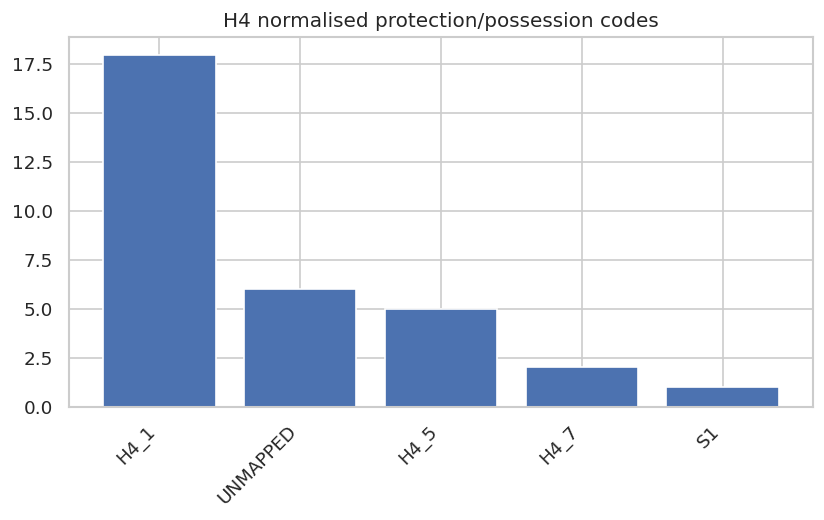

In [6]:
review_ids = rd.select_review_topics(
    h4,
    hyp=HYP,
    lex_idx=lex_idx,
    ctx_idx=ctx_idx,
    adj_idx=adj_idx,
    force_ids=ids_47,
    per_code=3,
    seed=42,
)
packs = rd.show_review_set(
    cfg,
    h4,
    review_ids,
    hyp=HYP,
    lex_idx=lex_idx,
    ctx_idx=ctx_idx,
    adj_idx=adj_idx,
    code_col=CODE_COL,
    max_sentences=12,
)
ctx.save_markdown(
    rd.render_review_markdown(
        packs, title="H4 protection / possession — close-reading pack"
    ),
    "close_reading_pack",
)
ctx.save_table(
    h4[
        [
            "topic_id",
            "current_topic_label",
            "current_taxonomy_id",
            "current_taxonomy_name",
            "care_protection_code",
            "code_norm",
            "mixed_topic",
        ]
    ],
    "care_protection_topic_annotations",
)

fig, ax = plt.subplots(figsize=(8, 4))
vc = h4["code_norm"].fillna("UNMAPPED").value_counts()
ax.bar(vc.index.astype(str), vc.values)
ax.set_title("H4 normalised protection/possession codes")
plt.xticks(rotation=45, ha="right")
ctx.save_figure(fig, "h4_code_distribution")
plt.show()

Primary refined contrast later: external_protection / (possessive_claiming +
coercive_control). If either side stays extremely sparse → H4 underpowered.

print("H4 audit review complete.")